# Model Agreement for same prompt

In [16]:
#%%
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import matplotlib.colors as pltcolors

from pathlib import Path
from folktexts.analysis.setup import ACS_TASKS, LLM_MODELS, baselines
from folktexts.analysis.utils import key_to_model, get_metric, get_predictions, prettify_model_name, load_baselines, is_instruction_tuned
from folktexts.analysis.analysis import get_agreement_at_random, get_observed_agreement
from folktexts.llm_utils import get_model_size_B

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR/'overview_results_by_prompt_style.csv'

#tasks =ACS_TASKS.remove(3)

In [20]:
df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df = df[(df['num_shots'] == 0) & (df['prompt_style'] == 'bullet') & (df['prompt_connector'] == 'is')]
df.head()

,task,model,is_inst,bench_hash,num_shots,prompt_style,prompt_connector,eval_results_path,predictions_path
0,ACSIncome,google--gemma-2-27b,0,3535356034,0,bullet,is,results/0-bullet-is/model-google--gemma-2-27b/...,results/0-bullet-is/model-google--gemma-2-27b/...
1,ACSIncome,google--gemma-2-27b-it,1,1373954821,0,bullet,is,results/0-bullet-is/model-google--gemma-2-27b-...,results/0-bullet-is/model-google--gemma-2-27b-...
2,ACSIncome,meta-llama--Meta-Llama-3-70B,0,730840778,0,bullet,is,results/0-bullet-is/model-meta-llama--Meta-Lla...,results/0-bullet-is/model-meta-llama--Meta-Lla...
3,ACSIncome,meta-llama--Meta-Llama-3-8B,0,2459590627,0,bullet,is,results/0-bullet-is/model-meta-llama--Meta-Lla...,results/0-bullet-is/model-meta-llama--Meta-Lla...
4,ACSIncome,google--gemma-2-9b,0,2644333273,0,bullet,is,results/0-bullet-is/model-google--gemma-2-9b/m...,results/0-bullet-is/model-google--gemma-2-9b/m...


In [23]:
baseline_scores, baseline_evals = load_baselines(baselines=baselines, tasks=ACS_TASKS)

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSIncome'.
- LR: Load predictions from 'results/baselines/LR_task-ACSIncome'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSIncome'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSIncome'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSEmployment'.
- LR: Load predictions from 'results/baselines/LR_task-ACSEmployment'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSEmployment'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSEmployment'.
Loading baselines for ACSMobility.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSMobility'.
- LR: Load predictions from 'results/baselines/LR_task-ACSMobility'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSMobility'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSMobili

## Agreement Heatmap

In [24]:
task = 'ACSIncome'
task_df = df[(df['task'] == task)]

# available models
models = task_df['model'].unique().tolist()
models.sort(key=lambda m: get_model_size_B(m) + int(is_instruction_tuned(m)))

In [25]:
# load predictions and measured accuracies
predictions = {}
accuracies = {}
for m in models: 
    data_m = task_df[task_df['model'] == m]
    assert data_m.shape[0] == 1, f"Expected 1 row for model {m} but found {data_m.shape[0]}"
    accuracies[m] = get_metric(data_m.iloc[0]['eval_results_path'], metric="accuracy")
    predictions[m] = get_predictions(data_m.iloc[0]['predictions_path'])

Create a grid for all model pairs

In [26]:
def get_agreement_matrix(models, dictionary: dict, fun: callable):
    matrix = torch.zeros(len(models),len(models))
    for i, mi in enumerate(models):
        for j in range(i,len(models)):
            mj = models[j]
            matrix[i][j] = fun(dictionary[mi], dictionary[mj])
            matrix[j][i] = matrix[i][j]
    return matrix

def plot_agreement_matrix(models, agreements:torch.Tensor, title: str="", file_name:str|Path=None, figsize=(8,8), vmin=0, vmax=1, cmap='magma_r', norm=None, exclude_diagonal=False):
    if exclude_diagonal:
        mask = torch.zeros_like(agreements).fill_diagonal_(torch.nan)
        agreements += mask
    if norm is None:
        norm = pltcolors.Normalize(vmin=vmin, vmax=vmax)
    fig, ax = plt.subplots(1,1,figsize=figsize)
    ax.set_title(title)
    num_models = agreements.shape[0]
    im = ax.imshow(agreements.numpy(),aspect='equal', extent=(0, num_models, 0, num_models), origin='lower', cmap=cmap, norm=norm)
    # im = ax.pcolormesh(agreements.numpy(), cmap='magma_r', vmin=0, vmax=1)
    ax.grid(False)
    ax.set_xticks(torch.arange(num_models)+0.5, [prettify_model_name(key_to_model(m)) for m in models], rotation=90)
    ax.set_yticks(torch.arange(num_models)+0.5, [prettify_model_name(key_to_model(m)) for m in models])

    # for y_index, y in enumerate(torch.arange(num_models)):
    #     for x_index, x in enumerate(torch.arange(num_models)):
    #         if y_index != x_index:
    #             label = f"{agreements[y_index, x_index].item():.2f}"
    #             text_x = x + 0.5
    #             text_y = y + 0.5
    #             ax.text(text_x, text_y, label, color='black', ha='center', va='center')

    plt.colorbar(im,fraction=0.046, pad=0.04)
    if file_name:
        plt.savefig(file_name)
    plt.show()

def plot_ratio_agreeements(models, observed, random, title="ratio", figsize=(5,5)):
    print("TODO - colorbar")
    ratio = observed/random
    mask = torch.zeros_like(ratio).fill_diagonal_(torch.nan)
    ratio += mask
    vmin = 0 # torch.floor(10*ratio[~torch.isnan(ratio)].min())/10
    vmax= 1.9 #torch.ceil(10*ratio[~torch.isnan(ratio)].max())/10
    max_abs = max(abs(vmin),abs(vmax))
    norm = pltcolors.TwoSlopeNorm(vmin=0, vcenter=1, vmax=max_abs)

    plot_agreement_matrix(models, ratio, title=title, figsize=figsize, cmap='RdBu', norm=norm)

In [27]:
baseline_acc = baseline_evals[task]['Constant']['accuracy'] 
models_above_baseline = [m for m in models if accuracies[m] > baseline_acc]

observed_agreememt = get_agreement_matrix(models_above_baseline, predictions, get_observed_agreement)
random_agreement = get_agreement_matrix(models_above_baseline, accuracies, get_agreement_at_random)
models_above_baseline

['mistralai--Mistral-7B-v0.1',
 'mistralai--Mistral-7B-Instruct-v0.2',
 'google--gemma-2-9b-it',
 'mistralai--Mixtral-8x7B-v0.1',
 'mistralai--Mixtral-8x7B-Instruct-v0.1',
 'meta-llama--Meta-Llama-3-70B',
 'meta-llama--Meta-Llama-3-70B-Instruct',
 'mistralai--Mixtral-8x22B-v0.1',
 'mistralai--Mixtral-8x22B-Instruct-v0.1']

Plot

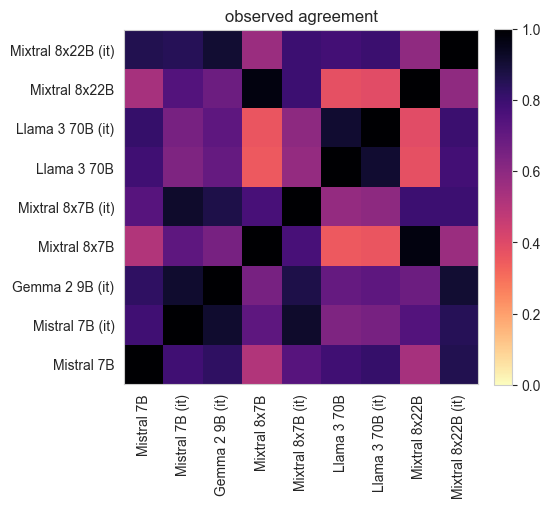

In [28]:
plot_agreement_matrix(models_above_baseline, observed_agreememt, "observed agreement", figsize=(5,5))

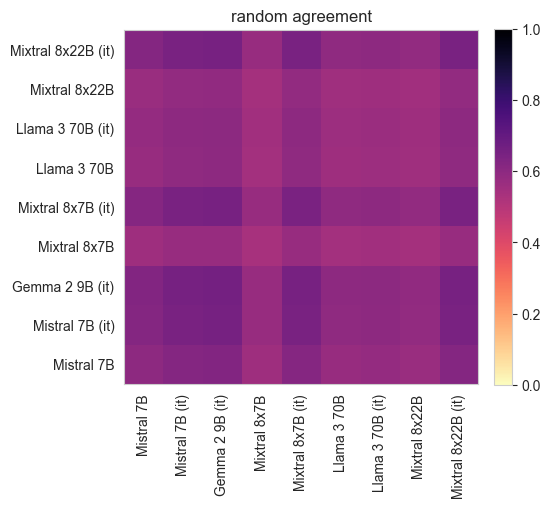

In [29]:
plot_agreement_matrix(models_above_baseline, random_agreement, "random agreement", figsize=(5,5))

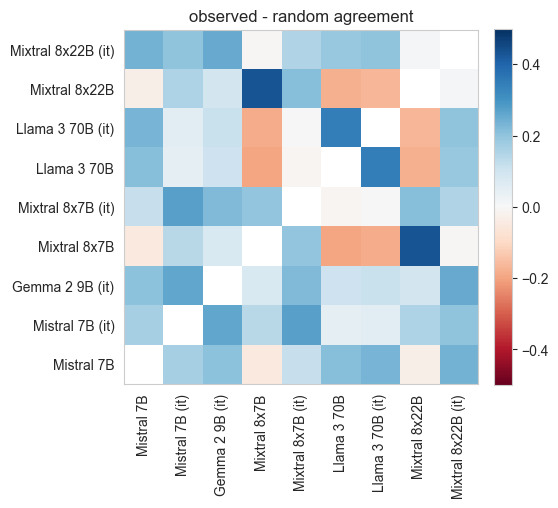

In [30]:
diff = observed_agreememt-random_agreement
mask = torch.zeros_like(observed_agreememt).fill_diagonal_(torch.nan)
diff += mask
vmin = torch.floor(10*diff[~torch.isnan(diff)].min())/10
vmax= torch.ceil(10*diff[~torch.isnan(diff)].max())/10
max_abs = max(abs(vmin),abs(vmax))
norm = pltcolors.Normalize(vmin=-max_abs, vmax=max_abs)

plot_agreement_matrix(models_above_baseline, diff, "observed - random agreement", figsize=(5,5), cmap='RdBu',vmin=vmin, vmax=vmax, norm=norm)

TODO - colorbar


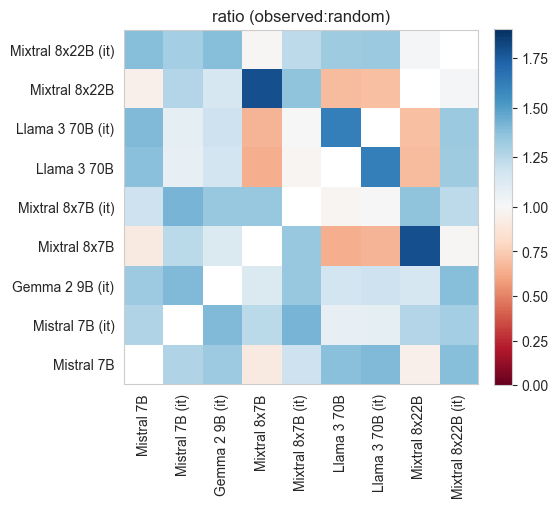

In [31]:
plot_ratio_agreeements(models_above_baseline, observed_agreememt, random_agreement, title="ratio (observed:random)")

Is there a difference between base models and instruction-tuned models?

In [32]:
models_base_above_baseline = [m for m in models_above_baseline if not is_instruction_tuned(key_to_model(m))]
models_it_above_baseline = [m for m in models_above_baseline if is_instruction_tuned(key_to_model(m))]

observed_agreememt_base = get_agreement_matrix(models_base_above_baseline, predictions, get_observed_agreement)
random_agreement_base = get_agreement_matrix(models_base_above_baseline, accuracies, get_agreement_at_random)

observed_agreememt_it = get_agreement_matrix(models_it_above_baseline, predictions, get_observed_agreement)
random_agreement_it = get_agreement_matrix(models_it_above_baseline, accuracies, get_agreement_at_random)

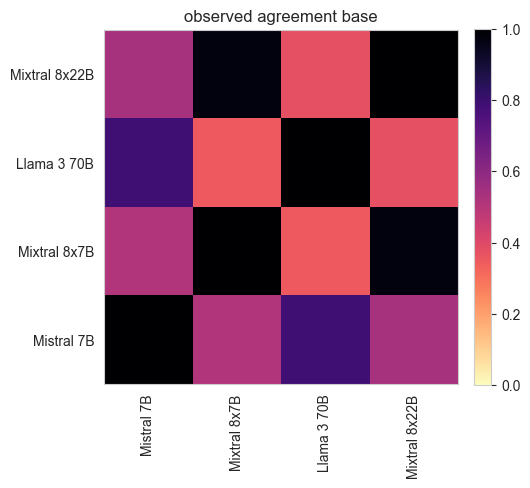

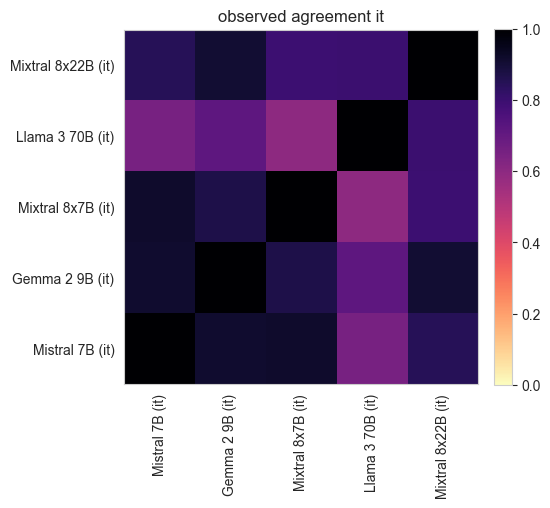

In [33]:
plot_agreement_matrix(models_base_above_baseline, observed_agreememt_base, "observed agreement base", figsize=(5,5))
plot_agreement_matrix(models_it_above_baseline, observed_agreememt_it, "observed agreement it", figsize=(5,5))

TODO - colorbar


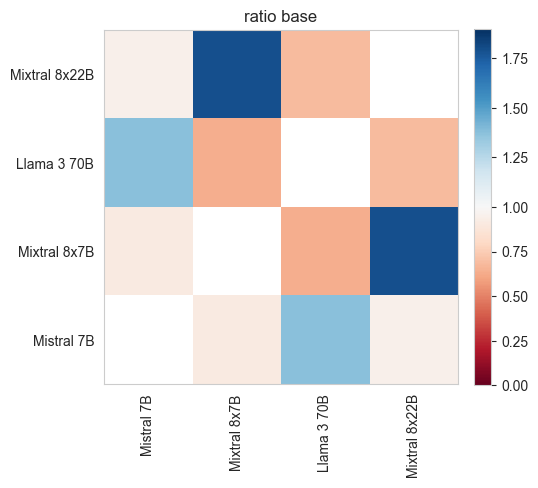

TODO - colorbar


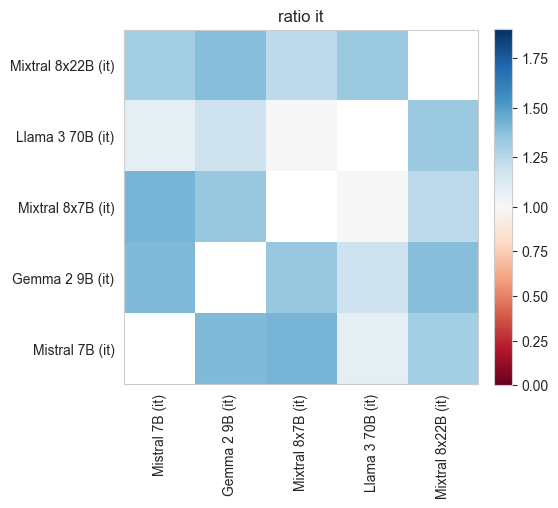

In [34]:
plot_ratio_agreeements(models_base_above_baseline, observed_agreememt_base, random_agreement_base, title="ratio base")
plot_ratio_agreeements(models_it_above_baseline, observed_agreememt_it, random_agreement_it, title="ratio it")
